# Image Inpainting  — ResNet-UNet

Bu notebook maskalanmış şəkilləri bərpa edən (inpainting) dərin öyrənmə modelini əhatə edir. Model kimi ResNet34 encoder əsaslı U-Net arxitekturası istifadə olunub, giriş RGB + maska (4 kanal) formatındadır.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/inpainting_project/archive.zip"
extract_path = "/content/inpainting"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Açıldı ✅")

Açıldı ✅


In [5]:
import os
import glob
import random
import time

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models

from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("İşlədilən cihaz:", device)

İşlədilən cihaz: cuda


## 1. Data hazırlığı

In [6]:
all_images = glob.glob("/content/inpainting/training/training/**/*.jpg", recursive=True)
print("Ümumi şəkil sayı:", len(all_images))

Ümumi şəkil sayı: 29410


Dataset hər şəkil üçün təsadüfi ölçüdə kvadrat maska yaradır. Val datasetində maskaların yeri və ölçüsü sabitlənib (`fixed_masks=True`), beləcə epoch-lar arasında val loss etibarlı müqayisə oluna bilir.

In [7]:
base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
])

class InpaintingDataset(Dataset):
    def __init__(self, image_paths, augment=True, min_mask=16, max_mask=48, fixed_masks=False, seed=42):
        self.image_paths = image_paths
        self.augment = augment
        self.min_mask = min_mask
        self.max_mask = max_mask
        self.fixed_masks = fixed_masks

        # Val üçün hər şəklin maska koordinatlarını əvvəlcədən sabitlə
        if fixed_masks:
            rng = random.Random(seed)
            self.mask_params = []
            for _ in range(len(image_paths)):
                size = rng.randint(min_mask, max_mask)
                top = rng.randint(0, 128 - size)
                left = rng.randint(0, 128 - size)
                self.mask_params.append((size, top, left))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = base_transform(img)

        if self.augment and random.random() > 0.5:
            img = transforms.functional.hflip(img)

        img = transforms.functional.to_tensor(img)
        h, w = img.shape[1], img.shape[2]

        if self.fixed_masks:
            mask_size, top, left = self.mask_params[idx]
        else:
            mask_size = random.randint(self.min_mask, self.max_mask)
            top = random.randint(0, h - mask_size)
            left = random.randint(0, w - mask_size)

        mask = torch.zeros(1, h, w)
        mask[:, top:top+mask_size, left:left+mask_size] = 1  # 1 = deşik

        masked_img = img * (1 - mask)
        model_input = torch.cat([masked_img, mask], dim=0)  # 4 kanal

        return model_input, img

In [8]:
from torch.utils.data import random_split

train_size = int(0.9 * len(all_images))
val_size = len(all_images) - train_size

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(len(all_images)), [train_size, val_size], generator=generator)

train_paths = [all_images[i] for i in train_indices.indices]
val_paths = [all_images[i] for i in val_indices.indices]

train_dataset = InpaintingDataset(train_paths, augment=True, min_mask=16, max_mask=48)
val_dataset = InpaintingDataset(val_paths, augment=False, min_mask=32, max_mask=32, fixed_masks=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Train: 26469, Val: 2941


## 2. Model arxitekturası

ResNet34 (ImageNet-də öncədən öyrədilmiş) encoder, U-Net tipli decoder ilə birləşdirilib. Giriş qatı 4 kanala (RGB + maska) uyğunlaşdırılıb ki, model deşiyin harada olduğunu bilsin.

In [9]:
class ResNetUNet(nn.Module):
    def __init__(self, out_channels=3):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        # 3 kanallı conv1-i 4 kanala genişləndir (RGB + maska)
        old_conv = resnet.conv1
        new_conv = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight
            new_conv.weight[:, 3:] = old_conv.weight.mean(dim=1, keepdim=True)
        resnet.conv1 = new_conv

        self.enc0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool0 = resnet.maxpool
        self.enc1 = resnet.layer1
        self.enc2 = resnet.layer2
        self.enc3 = resnet.layer3
        self.enc4 = resnet.layer4

        def up_block(in_ch, out_ch):
            return nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.up4 = up_block(512, 256)
        self.dec4 = self.conv_block(512, 256)

        self.up3 = up_block(256, 128)
        self.dec3 = self.conv_block(256, 128)

        self.up2 = up_block(128, 64)
        self.dec2 = self.conv_block(128, 64)

        self.up1 = up_block(64, 64)
        self.dec1 = self.conv_block(128, 64)

        self.up0 = up_block(64, 32)
        self.dec0 = self.conv_block(32, 32)

        self.out_conv = nn.Conv2d(32, out_channels, 1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        e0 = self.enc0(x)
        p0 = self.pool0(e0)
        e1 = self.enc1(p0)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        d4 = self.up4(e4)
        d4 = self.dec4(torch.cat([d4, e3], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e2], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e1], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e0], dim=1))

        d0 = self.up0(d1)
        d0 = self.dec0(d0)

        out = torch.sigmoid(self.out_conv(d0))
        return out

## 3. Loss funksiyası

MSE, L1 və perceptual (VGG əsaslı) loss-ların çəkili cəmi istifadə olunur. Əlavə olaraq, deşik daxilindəki xətaya daha çox əhəmiyyət vermək üçün `hole_weight` çəkisi tətbiq olunur.

In [10]:
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()

        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features[:16].eval()

        for param in vgg.parameters():
            param.requires_grad = False

        self.vgg = vgg

        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, output, target):
        output = (output - self.mean) / self.std
        target = (target - self.mean) / self.std

        output_features = self.vgg(output)
        target_features = self.vgg(target)

        return F.l1_loss(output_features, target_features)


perceptual_loss_fn = PerceptualLoss().to(device)


def combined_loss_v2(output, target, mask=None, alpha=1.0, beta=1.0, gamma=0.1, hole_weight=5.0):
    mse = F.mse_loss(output, target)
    l1 = F.l1_loss(output, target)
    perceptual = perceptual_loss_fn(output, target)
    loss = alpha * mse + beta * l1 + gamma * perceptual

    if mask is not None:
        hole_l1 = (torch.abs(output - target) * mask).sum() / (mask.sum() * 3 + 1e-8)
        loss = loss + hole_weight * hole_l1

    return loss

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 84.3MB/s]


## 4. Learning rate seçimi

Üç fərqli learning rate (0.001, 0.0005, 0.0001) qısa (3 epoch) təlimlə sınanıb, ən aşağı val loss verən dəyər (0.0005) əsas təlim üçün seçilib.

In [ ]:
def train_short(lr, n_epochs=3):
    model_test = ResNetUNet().to(device)
    optimizer_test = torch.optim.Adam(model_test.parameters(), lr=lr)

    val_loss_history = []

    for epoch in range(n_epochs):
        model_test.train()

        for masked, original in train_loader:
            masked, original = masked.to(device), original.to(device)

            optimizer_test.zero_grad()

            output = model_test(masked)
            mask = masked[:, 3:4]
            loss = combined_loss_v2(output, original, mask)

            loss.backward()
            optimizer_test.step()

        model_test.eval()
        running_val_loss = 0

        with torch.no_grad():
            for masked, original in val_loader:
                masked, original = masked.to(device), original.to(device)

                output = model_test(masked)
                mask = masked[:, 3:4]
                loss = combined_loss_v2(output, original, mask)

                running_val_loss += loss.item() * masked.size(0)

        epoch_val_loss = running_val_loss / len(val_dataset)
        val_loss_history.append(epoch_val_loss)

        print(f"lr={lr} | Epoch {epoch+1}/{n_epochs} | Val Loss: {epoch_val_loss:.5f}")

    return val_loss_history[-1]


candidate_lrs = [0.001, 0.0005, 0.0001]
results = {}

for lr in candidate_lrs:
    print(f"\n--- Sınanır: lr={lr} ---")
    final_val_loss = train_short(lr, n_epochs=3)
    results[lr] = final_val_loss

best_lr = min(results, key=results.get)

print(f"\n🏆 Ən yaxşı learning rate: {best_lr} (Val Loss: {results[best_lr]:.5f})")
print("Bütün nəticələr:", results)


--- Sınanır: lr=0.001 ---
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 116MB/s]


lr=0.001 | Epoch 1/3 | Val Loss: 0.05880
lr=0.001 | Epoch 2/3 | Val Loss: 0.05266
lr=0.001 | Epoch 3/3 | Val Loss: 0.05053

--- Sınanır: lr=0.0005 ---
lr=0.0005 | Epoch 1/3 | Val Loss: 0.08738
lr=0.0005 | Epoch 2/3 | Val Loss: 0.05460
lr=0.0005 | Epoch 3/3 | Val Loss: 0.04286

--- Sınanır: lr=0.0001 ---
lr=0.0001 | Epoch 1/3 | Val Loss: 0.05820
lr=0.0001 | Epoch 2/3 | Val Loss: 0.05568
lr=0.0001 | Epoch 3/3 | Val Loss: 0.04989

🏆 Ən yaxşı learning rate: 0.0005 (Val Loss: 0.04286)
Bütün nəticələr: {0.001: 0.0505280145619727, 0.0005: 0.04285605931866741, 0.0001: 0.0498918191925963}


## 5. Əsas təlim

Model 60 epoch üçün öyrədilir, `ReduceLROnPlateau` scheduler və 6 epoch patience_early_stopping istifadə olunur. Checkpoint hər epoch-dan sonra Drive-a yazılır, sessiya kəsilsə belə təlim qaldığı yerdən davam edə bilər.

In [16]:
best_lr = 0.0005

model4 = ResNetUNet().to(device)
optimizer4 = torch.optim.Adam(model4.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer4, mode='min', factor=0.5, patience=2)

save_dir = "/content/drive/MyDrive/inpainting_project"
os.makedirs(save_dir, exist_ok=True)
checkpoint_path4 = os.path.join(save_dir, "checkpoint_resnet_unet.pth")
best_model_path4 = os.path.join(save_dir, "best_model_resnet_unet.pth")

n_epochs = 60
patience_early_stop = 6
train_losses4 = []
val_losses4 = []
start_epoch = 0
best_val_loss = float("inf")
epochs_no_improve = 0

if os.path.exists(checkpoint_path4):
    checkpoint = torch.load(checkpoint_path4, map_location=device)
    model4.load_state_dict(checkpoint['model_state_dict'])
    optimizer4.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    train_losses4 = checkpoint['train_losses']
    val_losses4 = checkpoint['val_losses']
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float("inf"))
    epochs_no_improve = checkpoint.get('epochs_no_improve', 0)
    print(f"Checkpoint tapıldı, epoch {start_epoch}-dan davam edilir")

for epoch in range(start_epoch, n_epochs):
    start = time.time()

    model4.train()
    running_loss = 0
    for masked, original in train_loader:
        masked, original = masked.to(device), original.to(device)
        optimizer4.zero_grad()
        output = model4(masked)
        mask = masked[:, 3:4]
        loss = combined_loss_v2(output, original, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model4.parameters(), max_norm=1.0)
        optimizer4.step()
        running_loss += loss.item() * masked.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses4.append(epoch_train_loss)

    model4.eval()
    running_val_loss = 0
    with torch.no_grad():
        for masked, original in val_loader:
            masked, original = masked.to(device), original.to(device)
            output = model4(masked)
            mask = masked[:, 3:4]
            loss = combined_loss_v2(output, original, mask)
            running_val_loss += loss.item() * masked.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses4.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)

    current_lr = optimizer4.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_train_loss:.5f} | Val Loss: {epoch_val_loss:.5f} | LR: {current_lr:.6f} | Vaxt: {time.time()-start:.1f}s")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model4.state_dict(), best_model_path4)
        print(f"  ✅ Yeni ən yaxşı model saxlandı (Val Loss: {best_val_loss:.5f})")
    else:
        epochs_no_improve += 1

    torch.save({
        'epoch': epoch,
        'model_state_dict': model4.state_dict(),
        'optimizer_state_dict': optimizer4.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses4,
        'val_losses': val_losses4,
        'best_val_loss': best_val_loss,
        'epochs_no_improve': epochs_no_improve,
    }, checkpoint_path4)

    if epochs_no_improve >= patience_early_stop:
        print(f"\n⏹ Early stopping: {patience_early_stop} epoch ardıcıl yaxşılaşma olmadı. Epoch {epoch+1}-də dayandı.")
        break

print("\nÖyrətmə bitdi ✅")
print(f"Ən yaxşı Val Loss: {best_val_loss:.5f}")

Checkpoint tapıldı, epoch 55-dan davam edilir
Epoch 56/60 | Train Loss: 0.37027 | Val Loss: 0.33556 | LR: 0.000004 | Vaxt: 248.3s

⏹ Early stopping: 6 epoch ardıcıl yaxşılaşma olmadı. Epoch 56-də dayandı.

Öyrətmə bitdi ✅
Ən yaxşı Val Loss: 0.33407


Təlim epoch 56-da early stopping ilə dayanıb (6 epoch ardıcıl yaxşılaşma olmadığı üçün). Ən yaxşı val loss: 0.334.

## 6. Nəticələrin qiymətləndirilməsi

Ən yaxşı checkpoint (ən aşağı val loss-a malik epoch) yüklənir və bundan sonrakı bütün analizlər bu model üzərində aparılır.

In [12]:
best_model = ResNetUNet().to(device)
best_model.load_state_dict(torch.load(best_model_path4, map_location=device))
best_model.eval()
print("best_model yükləndi ✅")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 140MB/s]


best_model yükləndi ✅


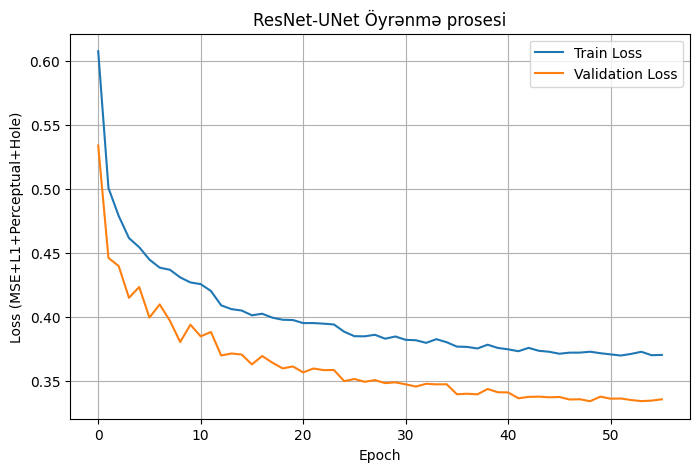

In [15]:
plt.figure(figsize=(8,5))
plt.plot(train_losses4, label="Train Loss")
plt.plot(val_losses4, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE+L1+Perceptual+Hole)")
plt.title("ResNet-UNet Öyrənmə prosesi")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "loss_graph_v3.png"))
plt.show()
plt.close()

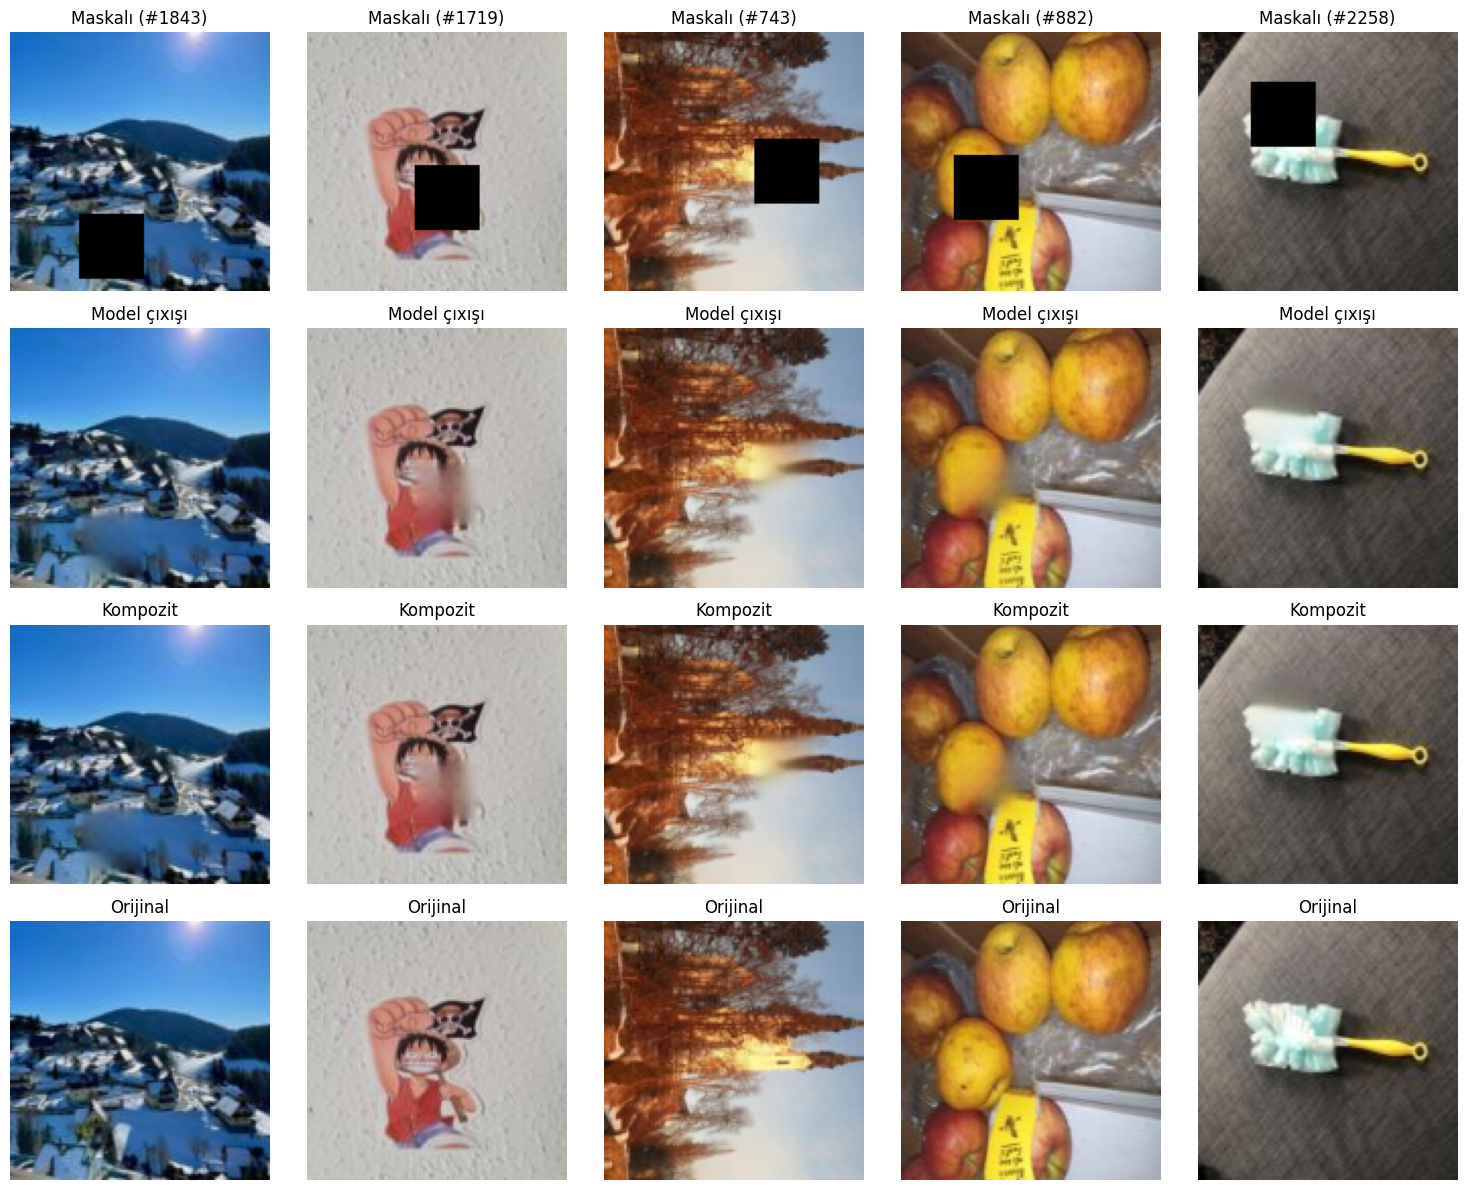

Orta PSNR (kompozit): 30.53 dB
Nümunə şəkillər saxlandı ✅


In [16]:
import random

def save_results(model, dataset, save_path, n_samples=5, seed=None):
    model.eval()
    if seed is not None:
        random.seed(seed)
    indices = random.sample(range(len(dataset)), n_samples)

    fig, axes = plt.subplots(4, n_samples, figsize=(3*n_samples, 12))
    psnrs = []
    with torch.no_grad():
        for col, idx in enumerate(indices):
            model_input, original = dataset[idx]
            output = model(model_input.unsqueeze(0).to(device)).cpu().squeeze(0)

            mask = model_input[3:4]
            masked_rgb = model_input[:3]
            composite = mask * output + (1 - mask) * original

            mse = F.mse_loss(composite, original).item()
            psnrs.append(10 * torch.log10(torch.tensor(1.0 / (mse + 1e-10))).item())

            axes[0, col].imshow(masked_rgb.permute(1,2,0));  axes[0, col].set_title(f"Maskalı (#{idx})")
            axes[1, col].imshow(output.permute(1,2,0).clamp(0,1));     axes[1, col].set_title("Model çıxışı")
            axes[2, col].imshow(composite.permute(1,2,0).clamp(0,1));  axes[2, col].set_title("Kompozit")
            axes[3, col].imshow(original.permute(1,2,0));    axes[3, col].set_title("Orijinal")
            for r in range(4):
                axes[r, col].axis("off")

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()
    print(f"Orta PSNR (kompozit): {sum(psnrs)/len(psnrs):.2f} dB")

save_results(best_model, val_dataset, os.path.join(save_dir, "visual_results_v3.png"))
print("Nümunə şəkillər saxlandı ✅")

 Model çıxışında bulanıqlıq müşahidə olunur — bu, MSE/L1 əsaslı loss funksiyalarının tipik nəticəsidir; GAN əsaslı adversarial loss əlavə etmək bu problemi azalda bilər.
 Yuxarıdakı PSNR yalnız 5 təsadüfi nümunənin ortasıdır; rəsmi nəticə bölmə 7-də tam val seti üzrə verilib.

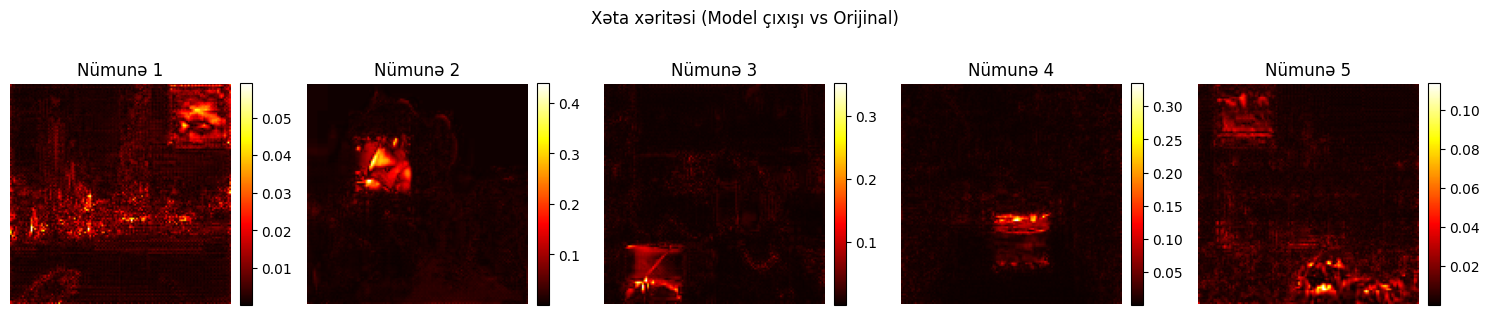

Xəta xəritələri saxlandı ✅


In [17]:
def show_error_maps(model, dataset, save_path, n_samples=5):
    model.eval()
    fig, axes = plt.subplots(1, n_samples, figsize=(3*n_samples, 3.5))
    with torch.no_grad():
        for i in range(n_samples):
            model_input, original = dataset[i]
            output = model(model_input.unsqueeze(0).to(device)).cpu().squeeze(0)

            error_map = (output - original).abs().mean(dim=0)

            im = axes[i].imshow(error_map, cmap="hot")
            axes[i].set_title(f"Nümunə {i+1}")
            axes[i].axis("off")
            fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    fig.suptitle("Xəta xəritəsi (Model çıxışı vs Orijinal)")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()

show_error_maps(best_model, val_dataset, os.path.join(save_dir, "error_maps_v3.png"))
print("Xəta xəritələri saxlandı ✅")

In [18]:
def evaluate_metrics(model, dataset, n_samples=100):
    model.eval()
    psnr_scores, ssim_scores = [], []
    with torch.no_grad():
        for i in range(min(n_samples, len(dataset))):
            model_input, original = dataset[i]
            input_tensor = model_input.unsqueeze(0).to(device)
            output = model(input_tensor).cpu().squeeze(0)

            mask = model_input[3:4]
            composite = mask * output + (1 - mask) * original

            output_np = composite.clamp(0,1).permute(1,2,0).numpy()
            orig_np = original.permute(1,2,0).numpy()

            psnr_scores.append(psnr(orig_np, output_np, data_range=1.0))
            ssim_scores.append(ssim(orig_np, output_np, channel_axis=2, data_range=1.0))

    print(f"Ortalama PSNR: {np.mean(psnr_scores):.2f} dB")
    print(f"Ortalama SSIM: {np.mean(ssim_scores):.4f}")
    return np.mean(psnr_scores), np.mean(ssim_scores)

In [19]:
!pip -q install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.4 MB/s eta 0:00:00


In [27]:
import lpips

lpips_fn = lpips.LPIPS(net='vgg').to(device)
lpips_fn.eval();

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/vgg.pth


## 7. Sadə U-Net ilə müqayisə

Layihənin ilkin mərhələsində öyrədilmiş, pretrained olmayan, sadə (encoder-decoder) U-Net modeli ilə ResNet-UNet-in nəticələri müqayisə olunur.

In [23]:
# Köhnə UNetInpainting class-ı (sadə, pretrained olmayan)
class UNetInpainting(nn.Module):
    def __init__(self, in_channels=3, base_ch=64):
        super().__init__()
        self.enc1 = self.conv_block(in_channels, base_ch)
        self.enc2 = self.conv_block(base_ch, base_ch*2)
        self.enc3 = self.conv_block(base_ch*2, base_ch*4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = self.conv_block(base_ch*4, base_ch*8)
        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, 2, stride=2)
        self.dec3 = self.conv_block(base_ch*8, base_ch*4)
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec2 = self.conv_block(base_ch*4, base_ch*2)
        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, 2, stride=2)
        self.dec1 = self.conv_block(base_ch*2, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_channels, 1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b); d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return torch.sigmoid(self.out_conv(d1))

In [24]:
# checkpoint_unet.pth-dən yükləyək (model2-nin saxlandığı fayl)
old_checkpoint = torch.load(os.path.join(save_dir, "checkpoint_unet.pth"))
model2_loaded = UNetInpainting().to(device)
model2_loaded.load_state_dict(old_checkpoint['model_state_dict'])
model2_loaded.eval()
print("Köhnə model (model2) yükləndi ✅")

Köhnə model (model2) yükləndi ✅


In [25]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def evaluate_fair(model, dataset, n_channels, name=""):
    model.eval()
    comp_psnr, hole_psnr, ssims, lp = [], [], [], []

    with torch.no_grad():
        for i in range(len(dataset)):
            x, y = dataset[i]
            out = model(x[:n_channels].unsqueeze(0).to(device)).cpu().squeeze(0)
            m = x[3:4]
            comp = (m * out + (1 - m) * y).clamp(0, 1)

            comp_np = comp.permute(1, 2, 0).numpy()
            y_np = y.permute(1, 2, 0).numpy()

            comp_psnr.append(psnr(y_np, comp_np, data_range=1.0))
            ssims.append(ssim(y_np, comp_np, channel_axis=2, data_range=1.0))

            hole_mse = (((out.clamp(0, 1) - y) ** 2) * m).sum() / (m.sum() * 3)
            hole_psnr.append(10 * torch.log10(1 / (hole_mse + 1e-10)).item())

            lp.append(lpips_fn((comp * 2 - 1).unsqueeze(0).to(device),
                               (y * 2 - 1).unsqueeze(0).to(device)).item())

    res = {
        "PSNR (kompozit)": np.mean(comp_psnr),
        "PSNR (deşik)": np.mean(hole_psnr),
        "SSIM": np.mean(ssims),
        "LPIPS": np.mean(lp),
    }
    print(f"--- {name} ({len(dataset)} şəkil) ---")
    for k, v in res.items():
        print(f"{k}: {v:.4f}")
    return res


res_old = evaluate_fair(model2_loaded, val_dataset, n_channels=3, name="Sadə U-Net")
res_new = evaluate_fair(best_model, val_dataset, n_channels=4, name="ResNet-UNet")

--- Sadə U-Net (2941 şəkil) ---
PSNR (kompozit): 32.4124
PSNR (deşik): 20.3712
SSIM: 0.9640
LPIPS: 0.0542
--- ResNet-UNet (2941 şəkil) ---
PSNR (kompozit): 35.1677
PSNR (deşik): 23.1265
SSIM: 0.9711
LPIPS: 0.0364


Hər iki model eyni val setində (2941 şəkil) eyni qaydada, kompozit ilə qiymətləndirilib. ResNet-UNet bütün metrikalarda üstündür. Modelin real keyfiyyətini yalnız maskalanmış sahə üzrə PSNR göstərir.

## Nəticə və Məhdudiyyətlər

ResNet-UNet sadə U-Net-dən bütün metrikalarda yaxşıdır.

Məhdudiyyətlər: çıxışda yüngül bulanıqlıq; yalnız kvadrat 32×32 maskalarla qiymətləndirmə; ayrıca test seti yoxdur; LR axtarışı loss-un ilkin versiyası ilə aparılıb.